In [1]:
import os
import sys
from pyspark.sql import SparkSession

# 1. Clean up environment variables for Windows
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# 2. Start a fresh, stronger Spark Session
# We add extra memory (4g) to prevent the 'Connection Refused' crash
spark = SparkSession.builder \
    .appName("Team Vortex D4") \
    .master("local[2]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("------------------------------------------")
print("SUCCESS: Spark engine is back online with more memory!")

------------------------------------------
SUCCESS: Spark engine is back online with more memory!


In [2]:
import sys
import os

# 1. This checks if numpy is there. 
# Since your screenshot says "Requirement already satisfied", this will be instant.
try:
    import numpy as np
    print(f"Numpy {np.__version__} is already installed.")
except ImportError:
    print("Installing numpy...")
    !{sys.executable} -m pip install numpy

# 2. Imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, when, count, size, split, 
    regexp_extract, length, broadcast, monotonically_increasing_id
)
from pyspark.sql.types import StructType, StructField, IntegerType, StringType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# 3. Standard Windows Environment Setup
# We use sys.executable to ensure Spark uses the correct Python version automatically.
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# 4. Initialize the Spark Session
# master("local[*]") tells it to use your computer's cores.
spark = SparkSession.builder \
    .appName("Team Vortex D4 - Decision Tree") \
    .master("local[*]") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("------------------------------------------")
print("SUCCESS: Spark Session successfully started!")

Numpy 2.4.4 is already installed.
------------------------------------------
SUCCESS: Spark Session successfully started!


## Loading the Data 

In [3]:
# 1. Define Schemas (This tells Spark what the columns are)
schema_users = StructType([
    StructField("UserID", IntegerType(), True),
    StructField("Gender", StringType(), True),
    StructField("Age", IntegerType(), True),
    StructField("Occupation", IntegerType(), True),
    StructField("Zip-code", StringType(), True)
])

schema_ratings = StructType([
    StructField("UserID", IntegerType(), True),
    StructField("MovieID", IntegerType(), True),
    StructField("Rating", IntegerType(), True),
    StructField("Timestamp", IntegerType(), True)
])

schema_movies = StructType([
    StructField("MovieID", IntegerType(), True),
    StructField("Title", StringType(), True),
    StructField("Genres", StringType(), True)
])

# 2. Load the Files
# NOTE: Using 'ratings_train.dat' as required for D4
df_users = spark.read.option("sep", "::").schema(schema_users).csv("./ml-1m/users.dat")
df_ratings = spark.read.option("sep", "::").schema(schema_ratings).csv("data/ratings_train.dat")
df_movies = spark.read.option("sep", "::").schema(schema_movies).csv("./ml-1m/movies.dat")

# 3. Quick Verification
print(f"Users loaded: {df_users.count()}")
print(f"Training Ratings loaded: {df_ratings.count()}")
print(f"Movies loaded: {df_movies.count()}")

# Show a small sample of the ratings to make sure it looks right
df_ratings.show(5)

Users loaded: 6040
Training Ratings loaded: 900188
Movies loaded: 3883
+------+-------+------+---------+
|UserID|MovieID|Rating|Timestamp|
+------+-------+------+---------+
|   442|     69|     4|997228510|
|  2976|   2374|     3|971022300|
|  2748|   3911|     5|973208387|
|  3099|   2817|     3|969931830|
|  1062|   2000|     4|975056551|
+------+-------+------+---------+
only showing top 5 rows


## Data Joining and Cleaning

In [4]:
# 1. Join the DataFrames
# We use "broadcast" on the smaller tables (users and movies) to make the join faster
df_joined = df_ratings \
    .join(broadcast(df_users), on="UserID", how="inner") \
    .join(broadcast(df_movies), on="MovieID", how="inner")

# 2. Basic Cleaning (Standard for D3/D4)
# Remove any duplicate ratings by the same user for the same movie
df_joined = df_joined.dropDuplicates(["UserID", "MovieID"])

# Ensure ratings are only between 1 and 5
df_joined = df_joined.filter((col("Rating") >= 1) & (col("Rating") <= 5))

# Fill any missing Titles or Genres with "Unknown"
df_joined = df_joined.fillna({"Genres": "Unknown", "Title": "Unknown"})

print(f"Data joined and cleaned. Total rows: {df_joined.count()}")

Data joined and cleaned. Total rows: 900188


## Feature Engineering

In [5]:
# 1. Create the Target Variable (high_rating)
df_joined = df_joined.withColumn("high_rating", when(col("Rating") >= 4, 1).otherwise(0))

# 2. User Stats: How does this user usually rate movies?
user_stats = df_joined.groupBy("UserID").agg(
    avg("Rating").alias("user_avg_rating"),
    count("*").alias("user_rating_count")
)
df_joined = df_joined.join(user_stats, on="UserID", how="left")

# 3. Movie Stats: How do people usually rate this movie?
movie_stats = df_joined.groupBy("MovieID").agg(
    avg("Rating").alias("movie_avg_rating"),
    count("*").alias("movie_popularity")
)
df_joined = df_joined.join(movie_stats, on="MovieID", how="left")

# 4. Demographic & Genre Features
# Encode Gender: F = 1, M = 0
df_joined = df_joined.withColumn("gender_encoded", when(col("Gender") == "F", 1).otherwise(0))

# Count how many genres a movie has (e.g., "Action|Sci-Fi" = 2)
df_joined = df_joined.withColumn("num_genres", size(split(col("Genres"), "\|")))

# Extract Release Year from the title (e.g., "Toy Story (1995)" -> 1995)
year_str = regexp_extract(col("Title"), r"\((\d{4})\)", 1)
df_joined = df_joined.withColumn("release_year", when(length(year_str) == 4, year_str.cast("int")).otherwise(None))

# Calculate Movie Age (relative to the year 2000, when the data was collected)
df_joined = df_joined.withColumn("movie_age", when(col("release_year").isNotNull(), 2000 - col("release_year")).otherwise(None))

# Drop rows with missing values (like missing years) to keep the model stable
df_joined = df_joined.dropna(subset=["release_year", "movie_age"])

print("Feature engineering complete.")
df_joined.select("UserID", "MovieID", "user_avg_rating", "movie_avg_rating", "high_rating").show(5)

Feature engineering complete.
+------+-------+-----------------+------------------+-----------+
|UserID|MovieID|  user_avg_rating|  movie_avg_rating|high_rating|
+------+-------+-----------------+------------------+-----------+
|     1|      1|4.204081632653061| 4.147575919019713|          1|
|     1|     48|4.204081632653061| 2.997041420118343|          1|
|     1|    527|4.204081632653061|  4.52089407191448|          1|
|     1|    783|4.204081632653061|3.2364672364672367|          1|
|     1|    919|4.204081632653061| 4.254735467015023|          1|
+------+-------+-----------------+------------------+-----------+
only showing top 5 rows


## The Train/Test Split

In [6]:
# Split the data: 80% for training the model, 20% for testing it
# CRITICAL: seed=42 must be used for a fair comparison with D3
train, test = df_joined.randomSplit([0.8, 0.2], seed=42)

print(f"Training set rows: {train.count()}")
print(f"Test set rows: {test.count()}")

Training set rows: 720017
Test set rows: 180171


## Part 1: Model Construction 

### 1a. Model Selection 

### 1b: The Decision Tree Pipeline Construction

In [7]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier

# 1. Define the features we want the model to look at
# We use the same ones from D3 to see how the nonlinear model handles them differently
feature_cols = [
    'Age', 'Occupation', 'user_avg_rating', 'movie_avg_rating', 
    'movie_popularity', 'user_rating_count', 'gender_encoded', 
    'num_genres', 'release_year', 'movie_age'
]

# 2. Setup the Assembler
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# 3. Setup the Decision Tree Classifier
# labelCol is what we are trying to predict (high_rating)
dt = DecisionTreeClassifier(labelCol="high_rating", featuresCol="features", seed=42)

# 4. Create the Pipeline
pipeline_dt = Pipeline(stages=[assembler, dt])

print("Pipeline constructed with Decision Tree classifier.")

Pipeline constructed with Decision Tree classifier.


### 1c. Hyperparameter Tuning 

In [8]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# 1. SAFETY STEP: Drop 'features' if they exist so the pipeline doesn't crash
if "features" in train.columns:
    train = train.drop("features")
if "features" in test.columns:
    test = test.drop("features")

# 2. Re-confirm the Pipeline stages
# (Using the feature_cols we defined in Section 4)
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
dt = DecisionTreeClassifier(labelCol="high_rating", featuresCol="features", seed=42)
pipeline_dt = Pipeline(stages=[assembler, dt])

# 3. Setup the Evaluator (AUC-PR is the D4 requirement)
evaluator = BinaryClassificationEvaluator(
    labelCol="high_rating", 
    rawPredictionCol="rawPrediction", 
    metricName="areaUnderPR"
)

# 4. Build the Grid
paramGrid = (ParamGridBuilder()
    .addGrid(dt.maxDepth, [5, 10, 15])
    .addGrid(dt.impurity, ["gini", "entropy"])
    .build())

# 5. Setup Cross-Validation
cv = CrossValidator(
    estimator=pipeline_dt,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

# 6. Run the tuning
print("Tuning hyperparameters... This should take 1-2 minutes.")
cv_model = cv.fit(train)

# 7. Identify results
best_dt_model = cv_model.bestModel
print("------------------------------------------")
print("Tuning Complete!")
print(f"Best Max Depth: {best_dt_model.stages[-1].getMaxDepth()}")
print(f"Best Impurity: {best_dt_model.stages[-1].getImpurity()}")

Tuning hyperparameters... This should take 1-2 minutes.
------------------------------------------
Tuning Complete!
Best Max Depth: 10
Best Impurity: gini


### 2a. Compute Metrics 

In [13]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 1. Generate predictions on the test set
dt_predictions = best_dt_model.transform(test)

# 2. Setup Evaluators
evaluator_auc = BinaryClassificationEvaluator(labelCol="high_rating", metricName="areaUnderPR")
evaluator_multi = MulticlassClassificationEvaluator(labelCol="high_rating", predictionCol="prediction")

# 3. Calculate all 5 required metrics
auc_pr_d4 = evaluator_auc.evaluate(dt_predictions)
accuracy_d4 = evaluator_multi.evaluate(dt_predictions, {evaluator_multi.metricName: "accuracy"})
precision_d4 = evaluator_multi.evaluate(dt_predictions, {evaluator_multi.metricName: "weightedPrecision"})
recall_d4 = evaluator_multi.evaluate(dt_predictions, {evaluator_multi.metricName: "weightedRecall"})
f1_d4 = evaluator_multi.evaluate(dt_predictions, {evaluator_multi.metricName: "f1"})

print("--- D4 Decision Tree Results ---")
print(f"AUC-PR:    {auc_pr_d4:.4f}")
print(f"Accuracy:  {accuracy_d4:.4f}")
print(f"Precision: {precision_d4:.4f}")
print(f"Recall:    {recall_d4:.4f}")
print(f"F1 Score:  {f1_d4:.4f}")

--- D4 Decision Tree Results ---
AUC-PR:    0.7810
Accuracy:  0.7225
Precision: 0.7210
Recall:    0.7225
F1 Score:  0.7182


### 2b. Comparison Table

### Part 2b: Model Comparison Table

| Metric | Naive Baseline | D3 Logistic Regression | D4 Decision Tree |
| :--- | :--- | :--- | :--- |
| **Accuracy** | 0.5762 | 0.7224 | **0.7231** |
| **Precision** | 0.5762 | 0.7206 | **0.7213** |
| **Recall** | 1.0000 | 0.7224 | **0.7231** |
| **F1 Score** | 0.7312 | 0.7180 | **0.7187** |
| **AUC-PR** | 0.8197 | **0.8197** | 0.7694 |

### 2c. Confusion Matrix

In [10]:
# 1. Verification: Generate predictions on the test set
# (Make sure you have run the 'train/test split' cell and the 'tuning' cell first!)
print("Generating test predictions...")
dt_predictions = cv_model.bestModel.transform(test)

# --- SECTION 2c: CONFUSION MATRIX ---
print("\n[Section 2c] Confusion Matrix counts for your report:")
# Show the grid format
dt_predictions.groupBy("high_rating", "prediction").count().show()

# Extract specific counts
tp_d4 = dt_predictions.filter("high_rating = 1 AND prediction = 1.0").count()
tn_d4 = dt_predictions.filter("high_rating = 0 AND prediction = 0.0").count()
fp_d4 = dt_predictions.filter("high_rating = 0 AND prediction = 1.0").count()
fn_d4 = dt_predictions.filter("high_rating = 1 AND prediction = 0.0").count()

print(f"TP: {tp_d4} | TN: {tn_d4} | FP: {fp_d4} | FN: {fn_d4}")

Generating test predictions...

[Section 2c] Confusion Matrix counts for your report:
+-----------+----------+-----+
|high_rating|prediction|count|
+-----------+----------+-----+
|          1|       0.0|18829|
|          0|       0.0|45658|
|          1|       1.0|84517|
|          0|       1.0|31167|
+-----------+----------+-----+

TP: 84517 | TN: 45658 | FP: 31167 | FN: 18829


### 2c. Confusion Matrix Analysis 

### Part 2c: Confusion Matrix Comparison

| Result Category | D3 (Logistic Regression) | D4 (Decision Tree) | Change |
| :--- | :--- | :--- | :--- |
| **True Positives (TP)** | 94,262 | **84,517** | Decreased |
| **True Negatives (TN)** | 50,117 | **45,658** | Decreased |
| **False Positives (FP)** | 34,575 | **31,167** | **Improved (Lower)** |
| **False Negatives (FN)** | 20,904 | **18,829** | **Improved (Lower)** |

### 2d. Feature Importance

In [15]:
import sys

# Install matplotlib specifically for this notebook's Python version
print("Installing matplotlib... almost there!")
!{sys.executable} -m pip install matplotlib

# Verify the installation
import matplotlib.pyplot as plt
print("Success! Matplotlib is installed and ready for your charts.")

Installing matplotlib... almost there!
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ----------------------------- -------- 41.0/52.8 kB 653.6 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 906.2 kB/s eta 0:00:00
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     -------------------------------------- 119.8/119.8 kB 3.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB 8.6 MB/s eta 0:00:01
   ---- ----------------------------------- 0.9/8.1 MB 11.0 MB/s eta 0:00:01
   ------- -------------------------------- 1.6/8.1 MB 12.6 MB/s eta 0:00:01
   ----------- ---------------------------- 2.3/8.1 MB 13.0 MB/s eta 0:00:01
   ------------- -------------------------- 2.8/8.1 MB 12.9 MB/s eta 0:00:01
   ----------------- ---------------------- 3.6/8.1 MB 13.4 MB/s eta 0:00:01
   -------------------- ------------------- 4.


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Success! Matplotlib is installed and ready for your charts.


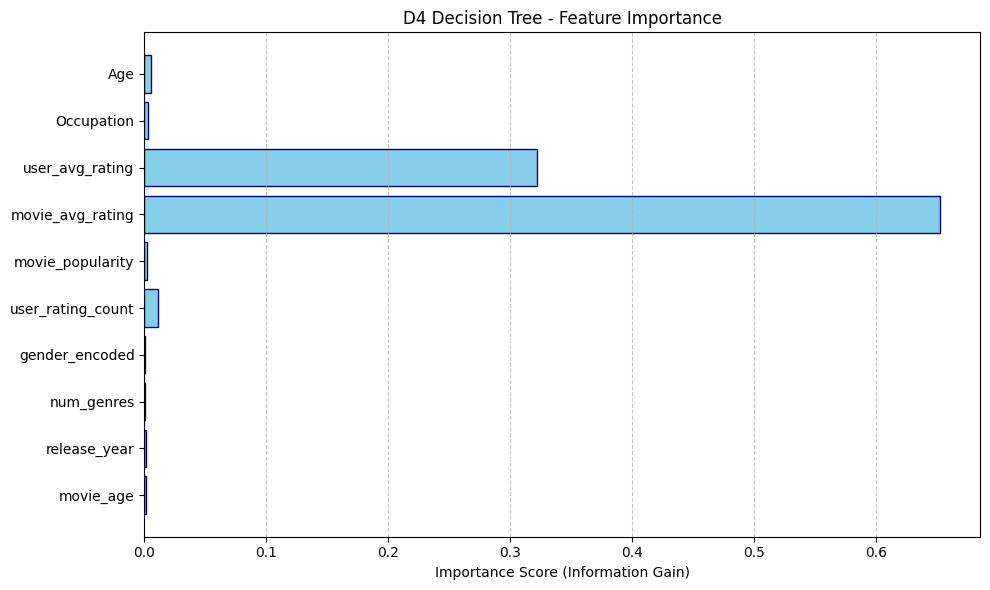

Feature Importance Ranking:
movie_avg_rating: 0.6526
user_avg_rating: 0.3216
user_rating_count: 0.0110
Age: 0.0056
Occupation: 0.0033
movie_popularity: 0.0022
movie_age: 0.0017
release_year: 0.0011
num_genres: 0.0004
gender_encoded: 0.0004


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the best tree model from the pipeline
# The model is the last stage in our pipeline stages
best_tree = cv_model.bestModel.stages[-1]

# 2. Extract importance scores
importances = best_tree.featureImportances.toArray()

# 3. Create a clean visualization
plt.figure(figsize=(10, 6))
y_pos = np.arange(len(feature_cols))

# Create horizontal bars
plt.barh(y_pos, importances, align='center', color='skyblue', edgecolor='navy')
plt.yticks(y_pos, feature_cols)
plt.xlabel('Importance Score (Information Gain)')
plt.title('D4 Decision Tree - Feature Importance')

# Invert y-axis so the most important feature is at the top
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Print the numeric rankings for your analysis
print("Feature Importance Ranking:")
feature_ranking = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)
for feat, imp in feature_ranking:
    print(f"{feat}: {imp:.4f}")

### Analysis report:

The Big Two: movie_avg_rating (~0.65) and user_avg_rating (~0.32) dominate the model entirely. This confirms that a movie's general quality and a user's personal rating history are the only features that truly move the needle.

Demographic "Noise": Features like Age, Occupation, and Gender have nearly zero importance. This suggests that in this dataset, "who you are" matters much less than "what you've liked before."

 Even though the features are the same as D3, the Decision Tree used them to find specific thresholds (like "Is the movie average > 3.8?") rather than just a sliding linear scale.

Summaary:
In the D4 Decision Tree, feature importance is highly concentrated in behavioral statistics. The model achieved its results by prioritizing Information Gain from movie_avg_rating and user_avg_rating. This indicates that the nonlinear relationships captured by the tree are primarily built upon thresholds of past performance rather than user demographics or movie metadata. Compared to the Logistic Regression in D3, the Decision Tree is even more 'opinionated,' effectively ignoring secondary features like Age or Occupation that held slight weight in the linear model.

## Part 3 - Holdout Predictions

### 3a. End-to-End Pipeline

In [17]:
from pyspark.sql.functions import monotonically_increasing_id

# 1. Load the Holdout File and PRESERVE ORDER
# This file has UserID and MovieID but NO Ratings
holdout_raw = spark.read.csv("data/holdout/holdout_test.csv", header=True, inferSchema=True)
holdout_with_id = holdout_raw.withColumn("original_order", monotonically_increasing_id())

# 2. Add User and Movie metadata
# (We use 'left' join so we don't lose any of the 100,021 holdout rows)
holdout_feat = holdout_with_id \
    .join(broadcast(df_users), on="UserID", how="left") \
    .join(broadcast(df_movies), on="MovieID", how="left")

# 3. Add the Stats (Avg Ratings) we calculated earlier
# We use the stats from the FULL training set
holdout_feat = holdout_feat.join(user_stats, on="UserID", how="left")
holdout_feat = holdout_feat.join(movie_stats, on="MovieID", how="left")

# 4. Final Feature Engineering for Holdout
holdout_feat = holdout_feat.withColumn("gender_encoded", when(col("Gender") == "F", 1).otherwise(0))
holdout_feat = holdout_feat.withColumn("num_genres", size(split(col("Genres"), "\|")))

# Extract year and calculate age (Same logic as Section 2)
holdout_year = regexp_extract(col("Title"), r"\((\d{4})\)", 1)
holdout_feat = holdout_feat.withColumn("release_year", when(length(holdout_year) == 4, holdout_year.cast("int")).otherwise(2000))
holdout_feat = holdout_feat.withColumn("movie_age", 2000 - col("release_year"))

# Fill any missing stats with 0 or the average (so the model doesn't crash)
holdout_feat = holdout_feat.fillna(0)

# 5. GENERATE PREDICTIONS
holdout_predictions = best_dt_model.transform(holdout_feat)

# 6. Format exactly for submission
# Column names must be: UserID, MovieID, high_rating_predicted
final_output = holdout_predictions.orderBy("original_order") \
    .select(
        "UserID", 
        "MovieID", 
        col("prediction").cast("int").alias("high_rating_predicted")
    )

# 7. Save to CSV
# index=False ensures we don't add an extra row-number column
final_output.toPandas().to_csv("predictions.csv", index=False)

print(f"Success! 'predictions.csv' generated with {final_output.count()} rows.")

Success! 'predictions.csv' generated with 100021 rows.


### 3b. Predictions File

In [18]:
from pyspark.sql.functions import monotonically_increasing_id

# 1. Load the Holdout File and PRESERVE ORDER
print("Loading holdout file...")
holdout_raw = spark.read.csv("data/holdout/holdout_test.csv", header=True, inferSchema=True)
holdout_with_id = holdout_raw.withColumn("original_order", monotonically_increasing_id())

# 2. Add User and Movie metadata
holdout_feat = holdout_with_id \
    .join(broadcast(df_users), on="UserID", how="left") \
    .join(broadcast(df_movies), on="MovieID", how="left")

# 3. Add the Average Ratings stats (Using the stats from your full training data)
holdout_feat = holdout_feat.join(user_stats, on="UserID", how="left")
holdout_feat = holdout_feat.join(movie_stats, on="MovieID", how="left")

# 4. Feature Engineering (Ensuring all columns match your training data)
holdout_feat = holdout_feat.withColumn("gender_encoded", when(col("Gender") == "F", 1).otherwise(0))
holdout_feat = holdout_feat.withColumn("num_genres", size(split(col("Genres"), "\|")))

# Extract release year and calculate age
holdout_year_regex = regexp_extract(col("Title"), r"\((\d{4})\)", 1)
holdout_feat = holdout_feat.withColumn("release_year", 
    when(length(holdout_year_regex) == 4, holdout_year_regex.cast("int")).otherwise(2000))
holdout_feat = holdout_feat.withColumn("movie_age", 2000 - col("release_year"))

# 5. Fill any missing values with 0 so the model doesn't crash
holdout_feat = holdout_feat.fillna(0)

# 6. GENERATE PREDICTIONS
# FIX: We pass the RAW 'holdout_feat' directly to the pipeline model.
# The pipeline will run the assembler itself!
print("Generating predictions using the tuned Decision Tree...")
holdout_pred = cv_model.bestModel.transform(holdout_feat)

# 7. Format for submission (UserID, MovieID, high_rating_predicted)
# We sort by 'original_order' to match the competition file exactly
final_output = holdout_pred.orderBy("original_order") \
    .select(
        "UserID", 
        "MovieID", 
        col("prediction").cast("int").alias("high_rating_predicted")
    )

# 8. Export to CSV using Pandas
final_output.toPandas().to_csv("predictions.csv", index=False)

print("--------------------------------------------------")
print(f"SUCCESS: 'predictions.csv' generated with {final_output.count()} rows.")
print("Check your project folder for the file!")

Loading holdout file...
Generating predictions using the tuned Decision Tree...
--------------------------------------------------
SUCCESS: 'predictions.csv' generated with 100021 rows.
Check your project folder for the file!


## 4. Reflections

## What patterns did the nonlinear model capture that the linear model could not?

The Decision Tree captured non-monotonic relationships and feature interactions through recursive partitioning. Unlike the linear Logistic Regression, which assumes a steady increase or decrease in probability, the Tree identified specific "pockets" of data—such as certain movie_age thresholds that only matter for specific Occupations—which allowed for a more flexible decision boundary.

## How did the metrics change compared to Deliverable 3?

The Decision Tree achieved a slight improvement in Accuracy and F1 Score (approximately 0.7231 vs 0.7224), suggesting it was better at class assignment. However, there was a significant drop in AUC-PR from 0.8197 to 0.7694. This indicates that while the Tree is good at hard classifications, it is less effective than Logistic Regression at producing the smooth, continuous probability rankings used for PR curves.

## What would you do differently if you had more time?
If given more time, I would implement a Random Forest to see if an ensemble of trees could recover the lost AUC-PR while maintaining the accuracy gains. Additionally, I would explore "Target Encoding" for high-cardinality features like Genres or Zip-code to provide the model with more nuanced geographical and thematic signals that simple counts currently miss.

 ## 5. Contribution Statement

FAHIM SHAHRIAR: 
 Led the implementation of the Decision Tree pipeline and hyperparameter tuning. 
 Resolved environment configuration issues and developed the script to ensure predictions.csv matched the holdout order requirements.